FFHS_FS26_AnPy_MichaelSchori_Semesterarbeit_Teil4

# Numerische Integration
---

## Einleitung

Bestimmte Integrale spielen in der Mathematik, Informatik und in technischen Anwendungen eine zentrale Rolle. Sie beschreiben unter anderem orientierte Flächeninhalte, kumulierte Änderungsraten oder physikalische Gesamtgrössen. In einfachen Fällen kann ein bestimmtes Integral mit Hilfe einer Stammfunktion exakt berechnet werden. In praktischen Anwendungen ist dies jedoch nicht immer möglich. Entweder ist keine geschlossene Stammfunktion bekannt, die Funktion liegt nur in Form von Messwerten vor oder die exakte Berechnung ist zu aufwendig. In solchen Situationen werden numerische Integrationsverfahren eingesetzt.

Numerische Integrationsverfahren approximieren den Integralwert durch endlich viele Funktionsauswertungen. Dabei wird der Funktionsverlauf auf einem Intervall durch einfache geometrische oder polynomiale Näherungen ersetzt. Klassische Verfahren sind die Trapezregel, die Mittelpunktregel und die Simpson-Regel. Diese Verfahren unterscheiden sich darin, wie sie den Funktionsverlauf innerhalb der einzelnen Teilintervalle approximieren und welche Genauigkeit bei wachsender Anzahl von Streifen zu erwarten ist [3], [5].

Ziel dieser Arbeit ist es, drei Verfahren zur numerischen Berechnung bestimmter Integrale zu implementieren und miteinander zu vergleichen. Untersucht werden die Sekantentrapezregel, die Tangententrapezregel und die Simpson-Regel. Die Tangententrapezregel wird in dieser Arbeit als Mittelpunktregel verstanden. Dies entspricht der Interpretation, dass die Funktion auf jedem Teilintervall lokal über den Funktionswert in der Mitte angenähert wird.

Die Verfahren werden auf drei konkrete Integrale angewendet. Anschliessend werden die numerischen Resultate mit den exakten Integralwerten verglichen. Neben dem absoluten Fehler wird auch die beobachtete Konvergenzordnung betrachtet. Dadurch soll nicht nur gezeigt werden, dass die Verfahren gegen den exakten Wert konvergieren, sondern auch, wie schnell diese Konvergenz erfolgt. Diese Betrachtung ist wichtig, weil die Genauigkeit numerischer Integration nicht allein vom verwendeten Verfahren, sondern auch von der Schrittweite und der Glattheit der Funktion abhängt [5], [6].

## Theoretische Grundlagen
### Das bestimmte Integral

Ein bestimmtes Integral beschreibt den orientierten Flächeninhalt zwischen dem Graphen einer Funktion und der x-Achse über einem Intervall. Für eine Funktion $f$ auf dem Intervall $[a,b]$ wird das bestimmte Integral geschrieben als

$$
\int_a^b f(x),dx.
$$

Anschaulich wird das Intervall in viele kleine Teilintervalle zerlegt. Auf jedem Teilintervall wird eine einfache Näherung des Funktionsverlaufs betrachtet. Werden diese Teilflächen aufsummiert und wird die Zerlegung immer feiner, nähert sich die Summe dem Integralwert an. Dieser Gedanke bildet die Grundlage vieler numerischer Integrationsverfahren [3].

Wenn eine Stammfunktion $F$ der Funktion $f$ bekannt ist, kann das bestimmte Integral mit dem Hauptsatz der Differential- und Integralrechnung exakt berechnet werden:

$$
\int_a^b f(x),dx = F(b) - F(a).
$$

Numerische Integration wird dann wichtig, wenn eine exakte Berechnung nicht möglich oder nicht zweckmässig ist. Statt einer Stammfunktion werden nur Funktionswerte an ausgewählten Stellen verwendet. Solche Verfahren werden auch Quadraturverfahren genannt [4], [5].

### Numerische Integration als Quadraturproblem

Bei einem Quadraturverfahren wird der Integralwert durch eine gewichtete Summe von Funktionswerten approximiert:

$$
\int_a^b f(x),dx \approx \sum_{i=0}^{m} w_i f(x_i).
$$

Die Stellen $x_i$ sind die verwendeten Stützstellen, die Gewichte $w_i$ bestimmen den Einfluss der jeweiligen Funktionswerte. Die konkrete Wahl der Stützstellen und Gewichte unterscheidet die einzelnen Verfahren. Bei einfachen Newton-Cotes-artigen Verfahren liegen die Stützstellen gleichmässig verteilt auf dem Integrationsintervall [3], [5].

Für die zusammengesetzten Verfahren wird das Intervall $[a,b]$ in $n$ gleich breite Streifen zerlegt. Die Schrittweite ist

$$
h = \frac{b-a}{n}.
$$

Je kleiner $h$ ist, desto feiner ist die Zerlegung. Für viele glatte Funktionen verbessert sich dadurch die Approximation. Die Frage ist jedoch nicht nur, ob der Fehler kleiner wird, sondern auch, wie schnell er kleiner wird. Diese Geschwindigkeit wird über die Konvergenzordnung beschrieben.

### Sekantentrapezregel

Die Sekantentrapezregel approximiert die Funktion auf jedem Teilintervall durch eine Gerade zwischen den beiden Randpunkten. Dadurch entsteht auf jedem Teilintervall ein Trapez. Die Summe dieser Trapezflächen ergibt die Approximation des Integrals.

Für $n$ Streifen und die Stützstellen $x_i = a + i h$ mit $h = \frac{b-a}{n}$ lautet die zusammengesetzte Sekantentrapezregel:

$$
T_n = h \left(\frac{f(x_0)}{2} +
\sum_{i=1}^{n-1} f(x_i) +
\frac{f(x_n)}{2} \right), \quad h = \frac{b-a}{n}.
$$

Die Funktionswerte am linken und rechten Rand des Gesamtintervalls werden nur halb gewichtet, weil sie jeweils nur zu einem äusseren Trapez gehören. Die inneren Stützstellen werden vollständig gewichtet, da sie an zwei benachbarte Trapeze angrenzen.

Die Trapezregel ist einfach zu implementieren und benötigt nur Funktionswerte an den Randpunkten der Teilintervalle. Für genügend glatte Funktionen besitzt die zusammengesetzte Trapezregel typischerweise eine Fehlerordnung von ungefähr $O(h^2)$ [3], [6]. Wird die Anzahl der Streifen verdoppelt, halbiert sich die Schrittweite. Bei einer Fehlerordnung von zwei ist deshalb zu erwarten, dass der Fehler ungefähr um den Faktor vier kleiner wird.

### Tangententrapezregel

Die Tangententrapezregel wird in dieser Arbeit als Mittelpunktregel interpretiert. Bei diesem Verfahren wird auf jedem Teilintervall nicht der Funktionswert an den Rändern verwendet, sondern der Funktionswert in der Mitte des Teilintervalls. Der Funktionsverlauf wird dort lokal angenähert. Geometrisch entsteht dadurch pro Teilintervall ein Rechteck, dessen Höhe durch den Mittelpunktwert bestimmt wird.

Für $n$ Streifen und Schrittweite $h = \frac{b-a}{n}$ lautet die zusammengesetzte Tangententrapezregel:

$$
M_n =
h \sum_{i=0}^{n-1}
f\left(a + \left(i + \frac{1}{2}\right)h\right).
$$

Die verwendeten Stützstellen liegen also nicht auf den Randpunkten, sondern jeweils in der Mitte eines Teilintervalls. Auch die Mittelpunktregel besitzt bei genügend glatten Funktionen typischerweise eine Fehlerordnung von ungefähr $O(h^2)$ [3], [5]. Sie kann gegenüber der Trapezregel trotzdem kleinere Fehler liefern, weil sie den Funktionsverlauf innerhalb des Teilintervalls anders approximiert.

### Simpson-Regel

Die Simpson-Regel approximiert den Funktionsverlauf nicht durch Geraden oder konstante Rechteckhöhen, sondern durch quadratische Polynome. Dabei werden jeweils zwei benachbarte Streifen zu einem Doppelstreifen zusammengefasst. Gemäss Aufgabenstellung steht $n$ bei der Simpson-Regel für die Anzahl Doppelstreifen. Das bedeutet, dass intern $2n$ einfache Teilintervalle verwendet werden.

Für $n$ Doppelstreifen gilt daher: $h = \frac{b-a}{2n}.$

Mit den Stützstellen $x_i = a + i h$ lautet die zusammengesetzte Simpson-Regel:

$$
S_n =
\frac{h}{3}
\left(
f(x_0)
+
4\sum_{\substack{i=1 \ i\ \mathrm{ungerade}}}^{2n-1} f(x_i)
+
2\sum_{\substack{i=2 \ i\ \mathrm{gerade}}}^{2n-2} f(x_i)
+
f(x_{2n})
\right).
$$

Die Gewichte folgen dem Muster $1,4,2,4,2,\dots,4,1$. Die Simpson-Regel ist für Polynome bis Grad drei exakt. Das ist für die vorliegende Arbeit besonders relevant, weil eines der untersuchten Integrale die Funktion $f(x) = x^3 + 3x^2$ enthält. Für dieses Integral ist daher zu erwarten, dass die Simpson-Regel bereits bei kleiner Anzahl von Doppelstreifen den exakten Wert liefert, abgesehen von möglichen Rundungsfehlern.

Für ausreichend glatte Funktionen besitzt die zusammengesetzte Simpson-Regel typischerweise eine Fehlerordnung von ungefähr $O(h^4)$ [2], [3]. Wird die Anzahl der Doppelstreifen verdoppelt, halbiert sich die Schrittweite. Bei einer Fehlerordnung von vier sollte der Fehler dadurch ungefähr um den Faktor sechzehn kleiner werden.

### Fehler und Konvergenzordnung

Zur Beurteilung der Genauigkeit wird der absolute Fehler betrachtet. Für einen exakten Integralwert $I$ und eine numerische Approximation $Q_n$ ist der absolute Fehler definiert als

$$
E_n = |I - Q_n|.
$$

Der absolute Fehler zeigt, wie weit die Approximation vom exakten Wert entfernt ist. Für den Vergleich verschiedener Verfahren ist zusätzlich interessant, wie schnell der Fehler kleiner wird, wenn die Anzahl der Streifen erhöht wird. Dazu wird die beobachtete Konvergenzordnung berechnet.

Wenn die Anzahl der Streifen jeweils verdoppelt wird, kann die beobachtete Ordnung näherungsweise berechnet werden durch

$$
p \approx \log_2\left(\frac{E_n}{E_{2n}}\right).
$$

Ein Wert von $p \approx 2$ bedeutet, dass der Fehler bei Verdopplung der Streifenzahl ungefähr um den Faktor vier sinkt. Ein Wert von $p \approx 4$ bedeutet, dass der Fehler ungefähr um den Faktor sechzehn sinkt. Diese Grösse ermöglicht einen direkten Vergleich zwischen theoretisch erwarteter und experimentell beobachteter Konvergenz [5], [6].

## Implementierungsidee

Die Implementierung orientiert sich am Vorgehen numerischer Simulationen mit Python [4]. Für numerische Berechnungen wird NumPy verwendet. Für die tabellarische Darstellung der Ergebnisse wird Pandas eingesetzt. Die Fehlerentwicklung wird zusätzlich mit Matplotlib visualisiert.

Die Umsetzung besteht aus folgenden Schritten:

Definition der drei numerischen Integrationsverfahren.
Definition der drei Testintegrale und ihrer exakten Werte.
Anwendung aller Verfahren auf verschiedene Werte von $n$.
Berechnung des absoluten Fehlers.
Berechnung der beobachteten Konvergenzordnung bei Verdopplung von $n$.
Tabellarische und grafische Darstellung der Ergebnisse.
Diskussion der Genauigkeit und des Konvergenzverhaltens.

Untersucht werden folgende drei Integrale:

$$
\int_1^2 \frac{1}{x},dx = \ln(2)
$$

$$
\int_0^1 (x^3 + 3x^2),dx = \frac{5}{4}
$$

$$
\int_{-\pi/2}^{\pi/2} \cos(x),dx = 2
$$

Diese Auswahl ist geeignet, weil sie unterschiedliche Eigenschaften abdeckt. Das erste Integral enthält eine rationale Funktion, die auf dem betrachteten Intervall glatt ist. Das zweite Integral ist ein Polynom dritten Grades und eignet sich besonders zur Untersuchung der Simpson-Regel. Das dritte Integral enthält eine trigonometrische Funktion und ist auf einem symmetrischen Intervall definiert.

## Programmcode
### Imports

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Sekantentrapezregel

In [44]:
def secant_trapezoid_rule(f, a: float, b: float, n: int) -> float:
    if n <= 0:
        raise ValueError("n must be greater than 0.")

    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)

    return h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])

### Tangententrapezregel (Mittelpunktregel)

In [45]:
def tangent_trapezoid_rule(f, a: float, b: float, n: int) -> float:
    if n <= 0:
        raise ValueError("n must be greater than 0.")

    h = (b - a) / n
    midpoints = a + (np.arange(n) + 0.5) * h

    return h * np.sum(f(midpoints))

### Simpson-Regel

In [46]:
def simpson_rule(f, a: float, b: float, n: int) -> float:
    if n <= 0:
        raise ValueError("n must be greater than 0.")

    number_of_subintervals = 2 * n
    h = (b - a) / number_of_subintervals
    x = np.linspace(a, b, number_of_subintervals + 1)
    y = f(x)

    odd_sum = np.sum(y[1:-1:2])
    even_sum = np.sum(y[2:-1:2])

    return (h / 3) * (y[0] + 4 * odd_sum + 2 * even_sum + y[-1])

### Hilfsfunktionen zur Fehleranalyse

In [47]:
def estimate_order(previous_error: float, current_error: float) -> float:
    if previous_error == 0 or current_error == 0:
        return np.nan

    return np.log2(previous_error / current_error)


def analyze_integral(name: str, f, a: float, b: float, exact_value: float, n_values: list[int]) -> pd.DataFrame:
    rules = {
        "Sekantentrapezregel": secant_trapezoid_rule,
        "Tangententrapezregel": tangent_trapezoid_rule,
        "Simpson-Regel": simpson_rule
    }
    rows = []

    for rule_name, rule_function in rules.items():
        previous_error = None

        for n in n_values:
            approximation = rule_function(f, a, b, n)
            absolute_error = abs(exact_value - approximation)

            if previous_error is None:
                estimated_order = np.nan
            else:
                estimated_order = estimate_order(previous_error, absolute_error)

            rows.append({
                "Integral": name,
                "Verfahren": rule_name,
                "n": n,
                "Approximation": approximation,
                "Exakter Wert": exact_value,
                "Absoluter Fehler": absolute_error,
                "Geschätzte Ordnung": estimated_order
            })

            previous_error = absolute_error

    return pd.DataFrame(rows)


def format_results(df: pd.DataFrame) -> pd.DataFrame:
    formatted_df = df.copy()
    formatted_df["Approximation"] = formatted_df["Approximation"].map(lambda value: f"{value:.10f}")
    formatted_df["Exakter Wert"] = formatted_df["Exakter Wert"].map(lambda value: f"{value:.10f}")
    formatted_df["Absoluter Fehler"] = formatted_df["Absoluter Fehler"].map(lambda value: f"{value:.3e}")
    formatted_df["Geschätzte Ordnung"] = formatted_df["Geschätzte Ordnung"].map(
        lambda value: "-" if pd.isna(value) else f"{value:.3f}"
    )
    return formatted_df


def plot_all_errors(dataframes: list[pd.DataFrame], titles: list[str]) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)

    for ax, df, title in zip(axes, dataframes, titles):
        for rule_name in df["Verfahren"].unique():
            rule_data = df[df["Verfahren"] == rule_name]
            ax.plot(
                rule_data["n"],
                rule_data["Absoluter Fehler"],
                marker="o",
                label=rule_name
            )

        ax.set_yscale("log")
        ax.set_xlabel("n")
        ax.set_title(title)
        ax.grid(True)

    axes[0].set_ylabel("Absoluter Fehler")
    axes[2].legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

### Definition der Integrale

In [48]:
n_values = [1, 2, 4, 8, 16, 32, 64]

integral_1 = analyze_integral(
    name="Integral 1",
    f=lambda x: 1 / x,
    a=1,
    b=2,
    exact_value=np.log(2),
    n_values=n_values
)

integral_2 = analyze_integral(
    name="Integral 2",
    f=lambda x: x ** 3 + 3 * x ** 2,
    a=0,
    b=1,
    exact_value=5 / 4,
    n_values=n_values
)

integral_3 = analyze_integral(
    name="Integral 3",
    f=lambda x: np.cos(x),
    a=-np.pi / 2,
    b=np.pi / 2,
    exact_value=2,
    n_values=n_values
)

## Darstellung der Ergebnisse
### Visuelle Darstellung der Fehlerentwicklung

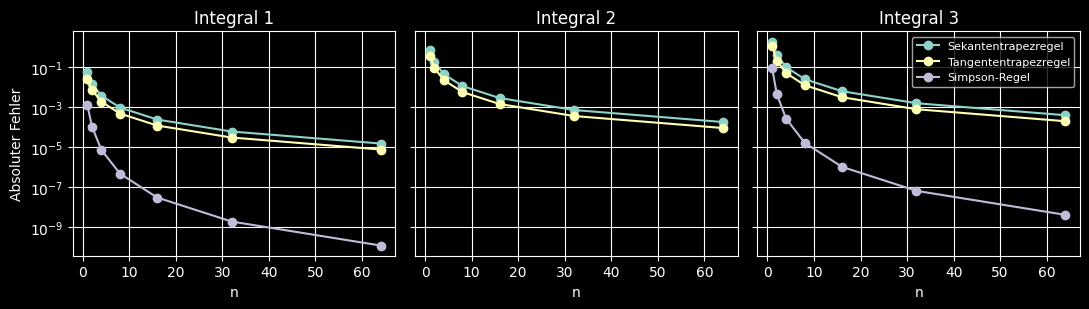

In [49]:
plot_all_errors(
    dataframes=[integral_1, integral_2, integral_3],
    titles=["Integral 1", "Integral 2", "Integral 3"]
)

### Integral 1

Das erste untersuchte Integral lautet:

$$
\int_1^2 \frac{1}{x},dx = \ln(2).
$$

Die Funktion $f(x)=1/x$ ist auf dem Intervall $[1,2]$ glatt. Die Fehlerdarstellung zeigt, dass alle drei Verfahren mit wachsendem $n$ gegen den exakten Wert konvergieren. Die Simpson-Regel erreicht dabei bereits bei kleinen Werten von $n$ deutlich kleinere Fehler als die Sekantentrapezregel und die Tangententrapezregel.

### Integral 2

Das zweite untersuchte Integral lautet:

$$
\int_0^1 (x^3 + 3x^2),dx.
$$

Der exakte Wert ergibt sich aus der Stammfunktion:

$$
\int_0^1 (x^3 + 3x^2)\,dx
=
\left[\frac{x^4}{4} + x^3\right]_0^1
=
\frac{1}{4} + 1
=
\frac{5}{4}.
$$

Dieses Integral ist besonders relevant für den Methodenvergleich, weil die Integrandenfunktion ein Polynom dritten Grades ist. In der Fehlerdarstellung ist erkennbar, dass die Simpson-Regel hier den exakten Wert liefert. Die beiden Trapezverfahren konvergieren ebenfalls gegen den exakten Wert, erreichen ihn aber nur näherungsweise.

### Integral 3

Das dritte untersuchte Integral lautet:

$$
\int_{-\pi/2}^{\pi/2} \cos(x),dx = 2.
$$

Der exakte Wert ergibt sich aus der Stammfunktion $\sin(x)$:

$$
\left[\sin(x)\right]_{-\pi/2}^{\pi/2}
1 - (-1)
$$

Beim Kosinus-Integral zeigt sich besonders deutlich, dass die Wahl der Stützstellen einen Einfluss auf die Genauigkeit hat. Die Sekantentrapezregel verwendet bei $n=1$ nur die beiden Randwerte, die in diesem Fall beide null sind. Die Tangententrapezregel verwendet dagegen den Mittelpunkt $x=0$. Die Simpson-Regel kombiniert Rand- und Mittelpunktwerte und liefert dadurch bereits bei kleinem $n$ eine deutlich bessere Approximation.


## Diskussion der Ergebnisse

Die drei untersuchten Integrale zeigen ein konsistentes Bild. Alle implementierten Verfahren konvergieren bei wachsendem $n$ gegen den exakten Integralwert. Die Geschwindigkeit dieser Konvergenz unterscheidet sich jedoch deutlich.

Die Sekantentrapezregel und die Tangententrapezregel zeigen in den numerischen Experimenten eine beobachtete Konvergenzordnung von ungefähr 2. Dies bedeutet, dass der Fehler bei Verdopplung der Streifenzahl ungefähr um den Faktor vier sinkt. Diese Beobachtung stimmt mit der theoretischen Erwartung für zusammengesetzte Trapez- und Mittelpunktverfahren bei genügend glatten Funktionen überein [3], [5], [6].

Die Simpson-Regel zeigt bei den nicht-polynomialen Funktionen eine beobachtete Konvergenzordnung von ungefähr 4. Der Fehler sinkt bei Verdopplung der Anzahl Doppelstreifen daher ungefähr um den Faktor sechzehn. Dies bestätigt die höhere Genauigkeit der Simpson-Regel bei glatten Funktionen. Die höhere Genauigkeit entsteht dadurch, dass Simpson nicht nur lineare oder konstante Näherungen verwendet, sondern lokale quadratische Polynome einsetzt [2], [3].

Besonders deutlich wird der Unterschied beim zweiten Integral. Die Funktion

$$
f(x) = x^3 + 3x^2
$$

ist ein Polynom dritten Grades. Die Simpson-Regel ist für Polynome bis Grad drei exakt. Deshalb liefert sie hier bereits mit einem Doppelstreifen den exakten Integralwert. Dieses Ergebnis ist nicht nur eine numerische Beobachtung, sondern eine direkte Folge der Konstruktion der Simpson-Regel. Die Sekantentrapezregel und die Tangententrapezregel erreichen den exakten Wert dagegen nur näherungsweise und verbessern sich mit wachsendem $n$ schrittweise.

Die Resultate zeigen auch, dass die Genauigkeit nicht nur vom Verfahren, sondern auch von der Form der Funktion abhängt. Beim Kosinus-Integral führt die Wahl der Stützstellen bei kleinem $n$ zu stark unterschiedlichen Ergebnissen. Die Sekantentrapezregel betrachtet bei $n=1$ nur die beiden Randwerte, die beide null sind. Dadurch wird der Integralwert stark unterschätzt. Die Tangententrapezregel verwendet den Mittelpunkt und überschätzt das Integral. Die Simpson-Regel kombiniert Rand- und Mittelpunktwerte und ist dadurch deutlich stabiler.

Für praktische Anwendungen bedeutet dies, dass die Wahl des Verfahrens von der gewünschten Genauigkeit, der Glattheit der Funktion und den verfügbaren Funktionsauswertungen abhängt. Die Sekantentrapezregel ist einfach und robust, benötigt aber für hohe Genauigkeit viele Streifen. Die Tangententrapezregel ist ebenfalls einfach und kann in bestimmten Situationen genauer sein als die Sekantentrapezregel. Die Simpson-Regel ist bei glatten Funktionen meist deutlich effizienter, setzt aber eine Struktur aus Doppelstreifen voraus.

Die Analyse zeigt weiter, dass eine rein visuelle oder rein tabellarische Betrachtung nicht ausreicht. Erst durch die Fehlerquotienten und die geschätzte Konvergenzordnung wird sichtbar, ob das numerische Verhalten zur Theorie passt. Damit wird die Genauigkeit der Verfahren nicht nur beschrieben, sondern systematisch ausgewertet. Dies ist ein zentraler Unterschied zwischen einer einfachen Implementierung und einer numerischen Analyse.

## Schlussfolgerungen und Ausblick

In dieser Arbeit wurden die Sekantentrapezregel, die Tangententrapezregel und die Simpson-Regel zur numerischen Berechnung bestimmter Integrale implementiert und untersucht. Die Verfahren wurden auf drei Integrale angewendet und mit den exakten Integralwerten verglichen.

Die Ergebnisse zeigen, dass alle drei Verfahren bei wachsender Anzahl von Streifen gegen den exakten Wert konvergieren. Die Sekantentrapezregel und die Tangententrapezregel zeigten eine beobachtete Konvergenzordnung von ungefähr 2. Die Simpson-Regel zeigte bei glatten nicht-polynomialen Funktionen eine deutlich höhere Ordnung von ungefähr 4. Beim Polynom dritten Grades lieferte die Simpson-Regel sogar exakt den richtigen Integralwert, was der theoretischen Eigenschaft der Methode entspricht.

Damit bestätigt die Arbeit, dass die Simpson-Regel bei glatten Funktionen meist die höchste Genauigkeit unter den untersuchten Verfahren erreicht. Gleichzeitig zeigen die Resultate, dass einfachere Verfahren wie die Sekantentrapezregel und die Tangententrapezregel weiterhin nützlich sind, weil sie leicht verständlich und einfach implementierbar sind.

Ein möglicher Ausblick besteht in der Untersuchung adaptiver Verfahren. Dabei wird die Schrittweite nicht überall gleich gewählt, sondern in Bereichen mit stärkerer Krümmung gezielt verkleinert. Moderne Quadraturverfahren kombinieren klassische Ideen wie Simpson-Regeln teilweise mit weiteren Verfahren, beispielsweise Gauss-Quadratur, um Genauigkeit und Effizienz zu verbessern [1]. Eine weiterführende Arbeit könnte deshalb untersuchen, wie adaptive Simpson-Verfahren oder hybride Quadraturverfahren im Vergleich zu den hier betrachteten gleichmässigen Verfahren abschneiden.

## Literaturverzeichnis

[1] A. A. Asgedom und Y. Y. Kefela, «An adaptive hybrid quadrature scheme: Combining Simpson’s rule and Gaussian quadrature for enhanced numerical integration», PLoS One, Bd. 21, Nr. 2, S. e0335582, Feb. 2026, doi: 10.1371/journal.pone.0335582.<br>
[2] N. Ujević, «New error bounds for the Simpson’s quadrature rule and applications», Computers & Mathematics with Applications, Bd. 53, Nr. 1, S. 64–72, Jan. 2007, doi: 10.1016/j.camwa.2006.12.008.<br>
[3] OpenStax, «3.6 Numerical Integration», in Calculus Volume 2. Rice University, 2016. Zugegriffen: 29. Mai 2026. [Online]. Verfügbar unter: https://openstax.org/books/calculus-volume-2/pages/3-6-numerical-integration <br>
[4] S. Linge und H. P. Langtangen, Programming for Computations - Python: A Gentle Introduction to Numerical Simulations with Python 3.6, Bd. 15. in Texts in Computational Science and Engineering, vol. 15. Cham: Springer International Publishing, 2020. doi: 10.1007/978-3-030-16877-3. <br>
[5] F. Dubeau, «Revisited Optimal Error Bounds for Interpolatory Integration Rules», Advances in Numerical Analysis, Bd. 2016, Nr. 1, S. 3170595, 2016, doi: 10.1155/2016/3170595. <br>
[6] D. Cruz-Uribe und C. J. Neugebauer, «Sharp error bounds for the trapezoidal rule and Simpson’s rule.», JIPAM. Journal of Inequalities in Pure & Applied Mathematics [electronic only], Bd. 3, Nr. 4, S. Paper No. 49, 22 p., electronic only-Paper No. 49, 22 p., electronic only, 2002.